# KKBOX Churn Prediction — Exploratory Data Analysis

This notebook explores the raw datasets to understand data quality, feature distributions, and their relationship with churn.

**Steps:**
1. Load datasets
2. Target variable analysis
3. Merge raw data for EDA
4. Data quality assessment
5. Demographic feature analysis
6. Transaction behavior analysis
7. Temporal analysis
8. EDA summary

## Step 0 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Step 1 — Load Datasets

Three separate CSV files are loaded and linked by `msno` (hashed user ID):
- **train_v2.csv** — churn labels: one row per user (`msno`, `is_churn`)
- **members_v3.csv** — user demographics: age (`bd`), gender, city, registration info
- **transactions_v2.csv** — payment history: one row per transaction (a user can have many rows)

In [2]:
train        = pd.read_csv("../data/train_v2.csv")
members      = pd.read_csv("../data/members_v3.csv")
transactions = pd.read_csv("../data/transactions_v2.csv")

print("Train shape       :", train.shape)
print("Members shape     :", members.shape)
print("Transactions shape:", transactions.shape)

print("\nTrain columns      :", train.columns.tolist())
print("Members columns    :", members.columns.tolist())
print("Transactions cols  :", transactions.columns.tolist())

Train shape       : (970960, 2)
Members shape     : (6769473, 6)
Transactions shape: (1431009, 9)

Train columns      : ['msno', 'is_churn']
Members columns    : ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']
Transactions cols  : ['msno', 'payment_method_id', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'transaction_date', 'membership_expire_date', 'is_cancel']


## Step 2 — Target Variable Analysis

We examine the distribution of `is_churn` (0 = stayed, 1 = churned).

This is the first thing to check because **class imbalance** directly affects:
- Which metric to use (log loss, not accuracy)
- How to configure the model (`scale_pos_weight` in XGBoost)
- How to split the data (stratified split)

=== Churn Distribution ===
Not churned (0): 883,630  (91.0%)
Churned     (1): 87,330  (9.0%)


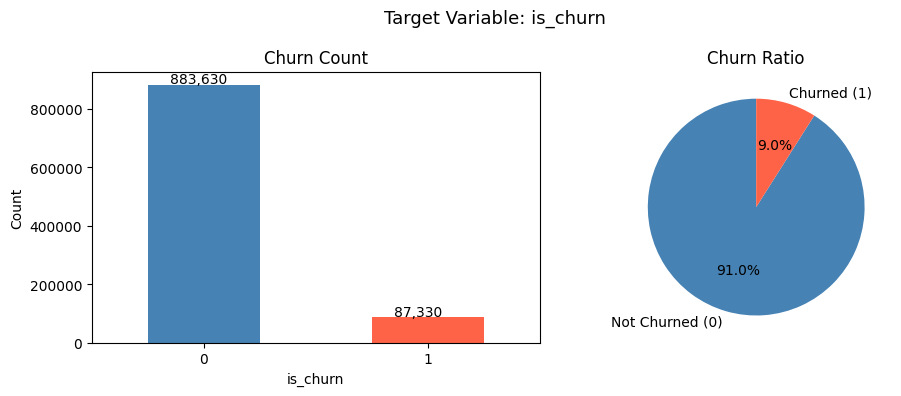

Conclusion: ~9% churn — highly imbalanced dataset.


In [3]:
counts = train["is_churn"].value_counts()
ratios = train["is_churn"].value_counts(normalize=True)

print("=== Churn Distribution ===")
print(f"Not churned (0): {counts[0]:,}  ({ratios[0]:.1%})")
print(f"Churned     (1): {counts[1]:,}  ({ratios[1]:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], rot=0)
axes[0].set_title("Churn Count")
axes[0].set_xlabel("is_churn")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + 0.1, p.get_height() + 5000))

axes[1].pie(counts, labels=["Not Churned (0)", "Churned (1)"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Churn Ratio")

plt.suptitle("Target Variable: is_churn", fontsize=13)
plt.tight_layout()
plt.show()

print("Conclusion: ~9% churn — highly imbalanced dataset.")

## Step 3 — Merge Raw Data for EDA

We merge all three tables using **left joins** on `msno` to create one DataFrame for exploration.

> **Note:** This merge is for EDA only. Because `transactions` has multiple rows per user, the result has more rows than `train`. For modeling, we aggregate transactions to one row per user first (see `Preprocessing.ipynb`).

In [4]:
df_raw = train.merge(members,      on="msno", how="left")
df_raw = df_raw.merge(transactions, on="msno", how="left")

print(f"train rows   : {len(train):,}")
print(f"df_raw rows  : {len(df_raw):,}  (expanded — multiple transactions per user)")
print(f"df_raw shape : {df_raw.shape}")

display(df_raw.sample(5))

train rows   : 970,960
df_raw rows  : 1,169,418  (expanded — multiple transactions per user)
df_raw shape : (1169418, 15)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
383847,1CIZkQZkAtXDI39BozBsBkRlHdOXK5A1Buev5vIG9gg=,0,6.0,23.0,female,9.0,20130107.0,37.0,30.0,149.0,149.0,1.0,20170309.0,20170408.0,0.0
836084,zAnL4ladTSb1aWK4ymcNfjutsw8QSQ8Ao8PW/Xh4iiY=,0,4.0,26.0,male,9.0,20070109.0,34.0,30.0,149.0,149.0,1.0,20170331.0,20170430.0,0.0
765344,CE664Ebtln8+vXJ+6VS6npZSPGWo08lZ/z/Yrh6+3P4=,0,1.0,0.0,NaN,7.0,20120207.0,41.0,30.0,149.0,149.0,1.0,20170306.0,20170407.0,0.0
292419,LRXrXQy5TbDnutyazKReXVRzxyowkaXxiNoBeg/Qv/Q=,0,1.0,0.0,NaN,7.0,20140911.0,41.0,30.0,149.0,149.0,1.0,20170311.0,20170411.0,0.0
651842,UweqOKgyKlWpCeO7Ylv2D8RzfJ2wki8rpAmU44XSKfU=,0,22.0,23.0,male,7.0,20131025.0,41.0,30.0,149.0,149.0,1.0,20150924.0,20190724.0,0.0


## Step 4 — Data Quality Assessment

Before analyzing features, we check for:
- **Missing values** — which columns have nulls and how many
- **Outliers** — values that are clearly wrong (e.g. age = -7168 or 2016)

This tells us what cleaning is needed before modeling.

In [5]:
# --- Missing values per column ---
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
summary = pd.DataFrame({"null_count": missing, "null_%": missing_pct})

print("=== Missing Values ===")
print(summary[summary["null_count"] > 0].to_string())

=== Missing Values ===
                        null_count  null_%
gender                      668413    57.2
city                        116836    10.0
bd                          116836    10.0
registered_via              116836    10.0
registration_init_time      116836    10.0
payment_method_id            37382     3.2
payment_plan_days            37382     3.2
plan_list_price              37382     3.2
actual_amount_paid           37382     3.2
is_auto_renew                37382     3.2
transaction_date             37382     3.2
membership_expire_date       37382     3.2
is_cancel                    37382     3.2


=== Age (bd) Range ===
Min : -3152.0
Max : 2016.0
Mean: 14.4

Rows with age outside [10, 80]: 553,520 (47.3%)


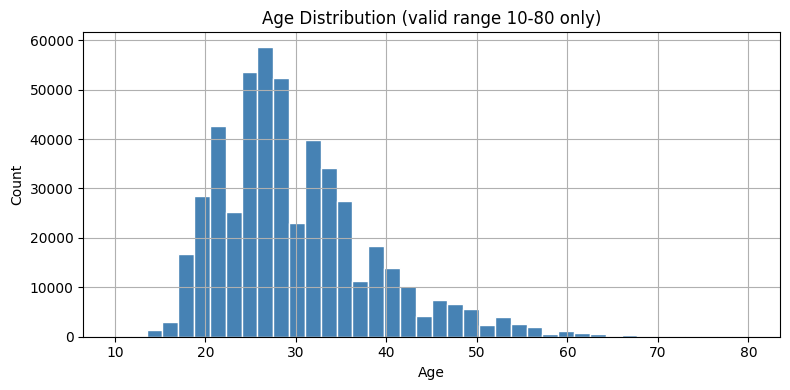

In [6]:
# --- Age (bd) outlier check ---
bd = df_raw["bd"]
print("=== Age (bd) Range ===")
print(f"Min : {bd.min()}")
print(f"Max : {bd.max()}")
print(f"Mean: {bd.mean():.1f}")

unrealistic = df_raw[(df_raw["bd"] < 10) | (df_raw["bd"] > 80)]
print(f"\nRows with age outside [10, 80]: {len(unrealistic):,} ({len(unrealistic)/len(df_raw):.1%})")

# Distribution of valid ages
valid_age = df_raw[(df_raw["bd"] >= 10) & (df_raw["bd"] <= 80)]["bd"]
plt.figure(figsize=(8, 4))
valid_age.hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Age Distribution (valid range 10-80 only)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Data quality issues found:**
- `gender`: ~57% missing — many users did not provide gender
- `bd` (age): values range from -7168 to 2016 — clearly data entry errors, need to clip to [10, 80]
- `city`, `registered_via`: ~10% missing — users not found in members table
- Transaction columns: ~3% missing — users with no transaction history

## Step 5 — Demographic Feature Analysis

We compare churn rates across demographic groups: age, gender, and city.

**Method:** `groupby(feature)["is_churn"].mean()` gives the churn rate per group.
A large difference between groups means the feature is a useful predictor.

=== Mean Age by Churn Status ===
is_churn
Not Churned    30.175506
Churned        28.327941


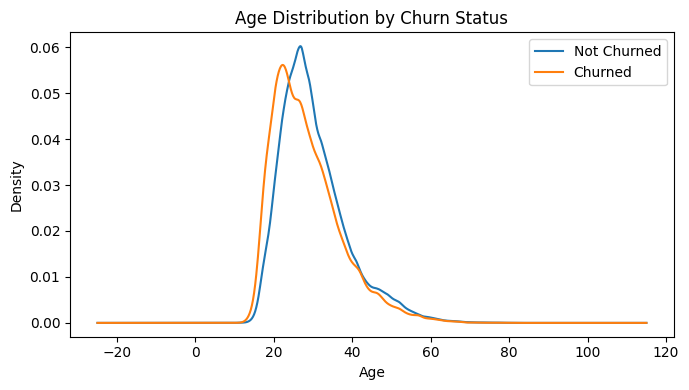

In [7]:
# --- Age vs Churn ---
# Use only valid ages [10, 80] to avoid outlier distortion
age_valid = df_raw[(df_raw["bd"] >= 10) & (df_raw["bd"] <= 80)]

print("=== Mean Age by Churn Status ===")
print(age_valid.groupby("is_churn")["bd"]
      .mean().rename({0: "Not Churned", 1: "Churned"}).to_string())

plt.figure(figsize=(7, 4))
for label, grp in age_valid.groupby("is_churn")["bd"]:
    grp.plot(kind="kde", label="Churned" if label == 1 else "Not Churned")
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.legend()
plt.tight_layout()
plt.show()

=== Churn Rate by City ===
city
21.0    0.173373
8.0     0.167883
12.0    0.165597
4.0     0.159406
5.0     0.158681
3.0     0.153846
14.0    0.152156
10.0    0.152148
19.0    0.151899
9.0     0.151625
16.0    0.148444
6.0     0.146283
13.0    0.146242
22.0    0.142301
15.0    0.141933
18.0    0.129561
11.0    0.128976
20.0    0.121979
7.0     0.121882
17.0    0.121701
1.0     0.102598


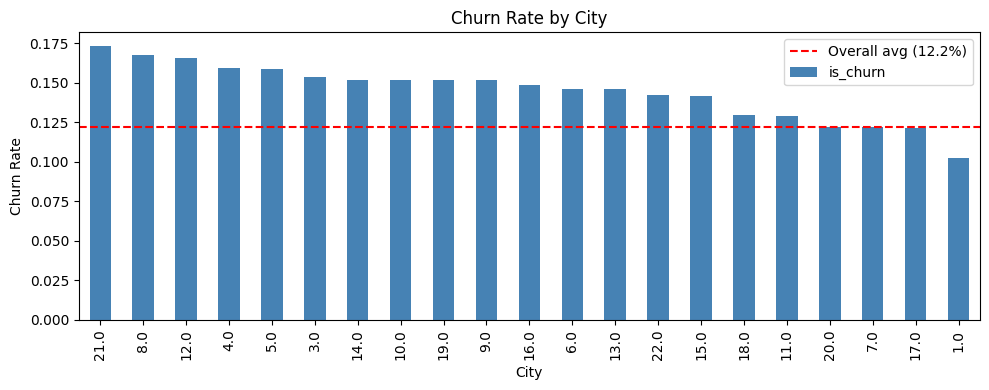

In [8]:
# --- City vs Churn ---
city_churn = df_raw.groupby("city")["is_churn"].mean().sort_values(ascending=False)

print("=== Churn Rate by City ===")
print(city_churn.to_string())

overall_avg = df_raw["is_churn"].mean()
avg_label = f"Overall avg ({overall_avg:.1%})"

plt.figure(figsize=(10, 4))
city_churn.plot(kind="bar", color="steelblue")
plt.axhline(y=overall_avg, color="red", linestyle="--", label=avg_label)
plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate")
plt.legend()
plt.tight_layout()
plt.show()

=== Churn Rate by Gender ===
gender
male      0.151975
female    0.151336


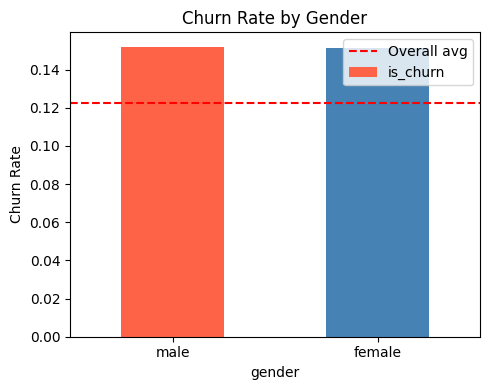

In [9]:
# --- Gender vs Churn ---
gender_churn = df_raw.groupby("gender")["is_churn"].mean().sort_values(ascending=False)

print("=== Churn Rate by Gender ===")
print(gender_churn.to_string())

plt.figure(figsize=(5, 4))
gender_churn.plot(kind="bar", color=["tomato", "steelblue", "gray"], rot=0)
plt.axhline(y=df_raw["is_churn"].mean(), color="red",
            linestyle="--", label="Overall avg")
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.legend()
plt.tight_layout()
plt.show()

**Findings:**
- **Age:** churned users are slightly older on average — weak signal
- **City:** churn rate varies from ~10% to ~17% across cities — useful feature
- **Gender:** male and female have nearly identical churn rates (~15%) — weak signal

## Step 6 — Transaction Behavior Analysis

We analyze how payment behavior differs between churned and non-churned users.

Key features examined:
- `is_cancel` — whether the user cancelled a transaction (1 = cancelled)
- `is_auto_renew` — whether auto-renewal was enabled (1 = enabled)
- `actual_amount_paid` — how much the user paid per transaction
- `payment_plan_days` — length of the subscription plan in days

=== Mean Values by Churn Status ===

is_cancel:
  Not Churned: 0.0131
  Churned    : 0.1725

is_auto_renew:
  Not Churned: 0.9405
  Churned    : 0.6991

actual_amount_paid:
  Not Churned: 131.2133
  Churned    : 268.8696

payment_plan_days:
  Not Churned: 30.0251
  Churned    : 65.2624


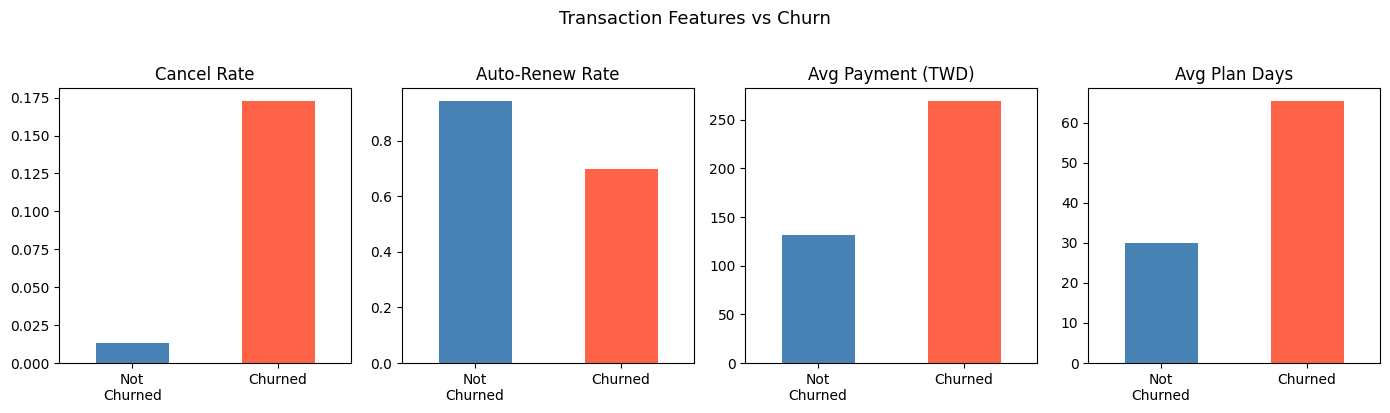

In [10]:
features = ["is_cancel", "is_auto_renew", "actual_amount_paid", "payment_plan_days"]
titles   = ["Cancel Rate", "Auto-Renew Rate", "Avg Payment (TWD)", "Avg Plan Days"]

print("=== Mean Values by Churn Status ===")
for feat in features:
    vals = df_raw.groupby("is_churn")[feat].mean()
    print(f"\n{feat}:")
    print(f"  Not Churned: {vals[0]:.4f}")
    print(f"  Churned    : {vals[1]:.4f}")

# Summary bar chart
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, feat, title in zip(axes, features, titles):
    vals = df_raw.groupby("is_churn")[feat].mean()
    vals.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], rot=0)
    ax.set_title(title)
    ax.set_xticklabels(["Not\nChurned", "Churned"])
    ax.set_xlabel("")

plt.suptitle("Transaction Features vs Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- `is_cancel`: **strongest signal** — churned users cancel 17% of transactions vs 1% for non-churned (13× more)
- `is_auto_renew`: churned users have lower auto-renew rate (70% vs 94%) — not renewing = planning to leave
- `actual_amount_paid`: churned users pay more — they buy long plans then cancel early
- `payment_plan_days`: churned users tend to buy longer plans

## Step 7 — Temporal Analysis

We analyze time-based signals by computing how many days remain on each user's membership.

**Why take the last transaction per user?**
Each user may have many transactions. The one with the latest `membership_expire_date` reflects the user's current subscription status — earlier transactions are outdated.

**Reference date:** `2017-03-01` — the snapshot date when the dataset was extracted.

- `days_left = membership_expire_date − 2017-03-01`
  - Positive → membership still active at snapshot
  - Negative → membership already expired
- `days_since_last_txn = 2017-03-01 − transaction_date`
  - Large value → user has not transacted recently → possible disengagement

=== Mean Days Left by Churn Status ===
is_churn
Not Churned     50.708947
Churned        122.588652

=== Mean Days Since Last Transaction ===
is_churn
Not Churned   -14.526486
Churned         7.848450


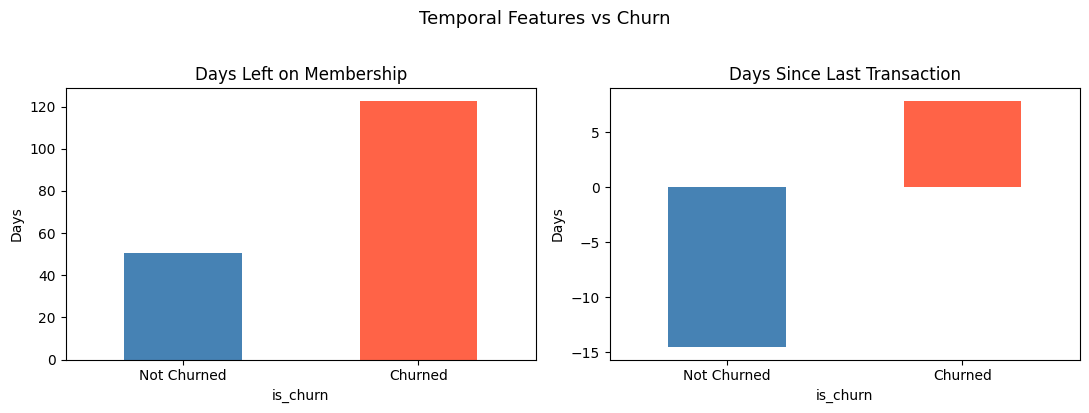

In [11]:
# Step 1: Convert integer dates (YYYYMMDD) to datetime
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"].astype(str), format="%Y%m%d", errors="coerce"
)
transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"].astype(str), format="%Y%m%d", errors="coerce"
)

# Step 2: Get the last transaction per user
# sort_values + tail(1) picks the row with the latest membership_expire_date
last_trans = (
    transactions
    .sort_values("membership_expire_date")
    .groupby("msno")
    .tail(1)
)

# Step 3: Merge with train — now one row per user
df_temporal = train.merge(last_trans, on="msno", how="left")

# Step 4: Compute temporal features
REFERENCE_DATE = pd.to_datetime("2017-03-01")
df_temporal["days_left"] = (
    df_temporal["membership_expire_date"] - REFERENCE_DATE
).dt.days
df_temporal["days_since_last_txn"] = (
    REFERENCE_DATE - df_temporal["transaction_date"]
).dt.days

# Step 5: Compare between churn groups
print("=== Mean Days Left by Churn Status ===")
print(df_temporal.groupby("is_churn")["days_left"]
      .mean().rename({0: "Not Churned", 1: "Churned"}).to_string())

print("\n=== Mean Days Since Last Transaction ===")
print(df_temporal.groupby("is_churn")["days_since_last_txn"]
      .mean().rename({0: "Not Churned", 1: "Churned"}).to_string())

# Step 6: Visualize
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["days_left", "days_since_last_txn"],
    ["Days Left on Membership", "Days Since Last Transaction"]
):
    df_temporal.groupby("is_churn")[col].mean().plot(
        kind="bar", ax=ax, color=["steelblue", "tomato"], rot=0)
    ax.set_title(title)
    ax.set_xticklabels(["Not Churned", "Churned"])
    ax.set_ylabel("Days")

plt.suptitle("Temporal Features vs Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- `days_left`: churned users have ~122 days remaining vs ~51 for non-churned
  → they cancel well before expiry, indicating a deliberate decision to leave
- `days_since_last_txn`: churned users transacted more recently
  → consistent with buying a plan then immediately cancelling

## Step 8 — EDA Summary

| Feature | Signal | Key Finding |
|---|---|---|
| `is_cancel` | ⭐⭐⭐ Strong | Churned users cancel 13× more often |
| `is_auto_renew` | ⭐⭐⭐ Strong | Churned users: 70% auto-renew vs 94% for non-churned |
| `days_left` | ⭐⭐⭐ Strong | Churned users cancel with ~122 days still remaining |
| `city` | ⭐⭐ Medium | Churn rate varies from 10% to 17% across cities |
| `actual_amount_paid` | ⭐⭐ Medium | Churned users pay more (buy long plans, cancel early) |
| `payment_plan_days` | ⭐⭐ Medium | Churned users tend to buy longer plans |
| `bd` (age) | ⭐ Weak | Slight difference in mean age |
| `gender` | ✗ None | Nearly identical churn rate for male/female |

**Next step:** Use these insights to guide feature engineering in `Preprocessing.ipynb`.
The strongest features (`is_cancel`, `is_auto_renew`, `days_left`) should be prioritized.